In [1]:
%pip install gymnasium numpy matplotlib pygame
# Note: pygame is needed for rendering certain environments

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random

# Set a seed for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries imported successfully!")

Libraries imported successfully!


Initial State: 0


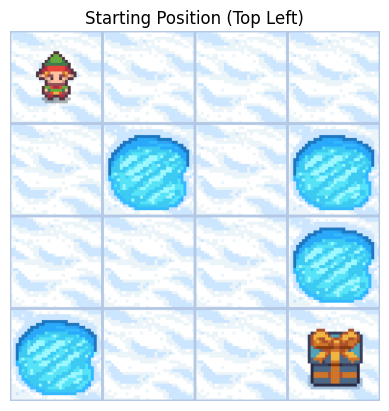

In [3]:
# Create the environment
# render_mode="rgb_array" allows us to capture frames for visualization later
env = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=False, render_mode="rgb_array")

# Reset the environment to start a new episode.
# It returns the initial state (observation) and some info.
state, info = env.reset(seed=SEED)

print(f"Initial State: {state}")

# Let's visualize the starting state
plt.imshow(env.render())
plt.axis('off')
plt.title("Starting Position (Top Left)")
plt.show()

In [4]:
print(f"Observation Space: {env.observation_space}")
print(f"Action Space: {env.action_space}")

# Details:
# Discrete(16) means there are 16 possible states (the 16 tiles on the 4x4 grid, numbered 0-15).
# Discrete(4) means there are 4 possible actions: 0: LEFT, 1: DOWN, 2: RIGHT, 3: UP

Observation Space: Discrete(16)
Action Space: Discrete(4)


Random Agent playing...


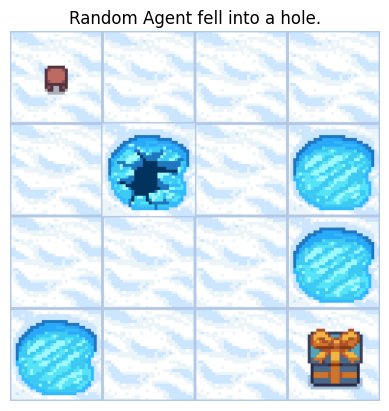

In [5]:
env_random = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=False, render_mode="rgb_array")
state, info = env_random.reset(seed=SEED)
done = False
steps = 0

print("Random Agent playing...")
while not done and steps < 20: # Limit steps just in case
    # TAKE A RANDOM ACTION
    action = env_random.action_space.sample()

    # Apply action to the environment
    # next_state: where we ended up
    # reward: 1 if reached goal, 0 otherwise
    # terminated: True if fell in hole or reached goal
    # truncated: True if episode went too long (not used much here)
    next_state, reward, terminated, truncated, info = env_random.step(action)

    done = terminated or truncated
    state = next_state
    steps += 1

# Visualize final state
plt.imshow(env_random.render())
plt.axis('off')
if reward == 1.0:
    plt.title("Random Agent reached the Goal! (Pure Luck)")
else:
    plt.title("Random Agent fell into a hole.")
plt.show()

env_random.close()

In [6]:
# 1. Initialize Environment and Hyperparameters
env = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=False)
# Note: We turn OFF rendering during training to make it fast.

state_space = env.observation_space.n
action_space = env.action_space.n

# Hyperparameters
total_episodes = 2000        # Total training episodes
learning_rate = 0.8          # Alpha: How fast we learn
discount_factor = 0.95       # Gamma: Importance of future rewards

# Exploration parameters
epsilon = 1.0                 # Exploration rate at start
max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.01            # Minimum exploration probability
decay_rate = 0.005            # Exponential decay rate for exploration

# 2. Initialize the Q-Table with zeros
q_table = np.zeros((state_space, action_space))

print("Q-Table shape:", q_table.shape)
print("Initial Q-Table (first few rows):\n", q_table[:5])

# List to store rewards for tracking progress
rewards_per_episode = []

# 3. The Training Loop
print("\nTraining started...")
for episode in range(total_episodes):
    state, info = env.reset()
    done = False
    total_reward_this_episode = 0

    for step in range(100): # Max steps per episode just in case
        # --- ACTION SELECTION (Epsilon-Greedy) ---
        exp_exp_tradeoff = random.uniform(0, 1)

        # If random number > epsilon -> EXPLOITATION (take best action)
        if exp_exp_tradeoff > epsilon:
            # np.argmax returns the index of the maximum value in the row
            action = np.argmax(q_table[state, :])
        # Else -> EXPLORATION (take random action)
        else:
            action = env.action_space.sample()

        # --- TAKE ACTION & GET FEEDBACK ---
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # --- Q-VALUE UPDATE (The Core Learning Step) ---
        # Find maximum Q-value for the NEXT state
        max_future_q = np.max(q_table[next_state, :])

        # The Bellman Equation update
        current_q = q_table[state, action]
        new_q = current_q + learning_rate * (reward + discount_factor * max_future_q - current_q)
        q_table[state, action] = new_q

        total_reward_this_episode += reward
        state = next_state

        if done:
            break

    # Decaying Epsilon: Reduce exploration probability over time
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    rewards_per_episode.append(total_reward_this_episode)

    if (episode+1) % 200 == 0:
        print(f"Episode {episode+1}/{total_episodes} finished. Current Epsilon: {epsilon:.4f}")

print("Training finished!")
env.close()

Q-Table shape: (16, 4)
Initial Q-Table (first few rows):
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Training started...
Episode 200/2000 finished. Current Epsilon: 0.3760
Episode 400/2000 finished. Current Epsilon: 0.1447
Episode 600/2000 finished. Current Epsilon: 0.0595
Episode 800/2000 finished. Current Epsilon: 0.0282
Episode 1000/2000 finished. Current Epsilon: 0.0167
Episode 1200/2000 finished. Current Epsilon: 0.0125
Episode 1400/2000 finished. Current Epsilon: 0.0109
Episode 1600/2000 finished. Current Epsilon: 0.0103
Episode 1800/2000 finished. Current Epsilon: 0.0101
Episode 2000/2000 finished. Current Epsilon: 0.0100
Training finished!


In [7]:
print("Final Q-Table (Learned knowledge):")
# Rounding for easier reading
print(np.round(q_table, 3))

# Interpret Row 0 (Start state):
# The highest value in row 0 tells the agent the best first move.
# Actions: 0: LEFT, 1: DOWN, 2: RIGHT, 3: UP
best_start_action = np.argmax(q_table[0, :])
action_map = {0: "Left", 1: "Down", 2: "Right", 3: "Up"}
print(f"\nBest action in starting state (State 0) appears to be: {action_map[best_start_action]}")

Final Q-Table (Learned knowledge):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Best action in starting state (State 0) appears to be: Left


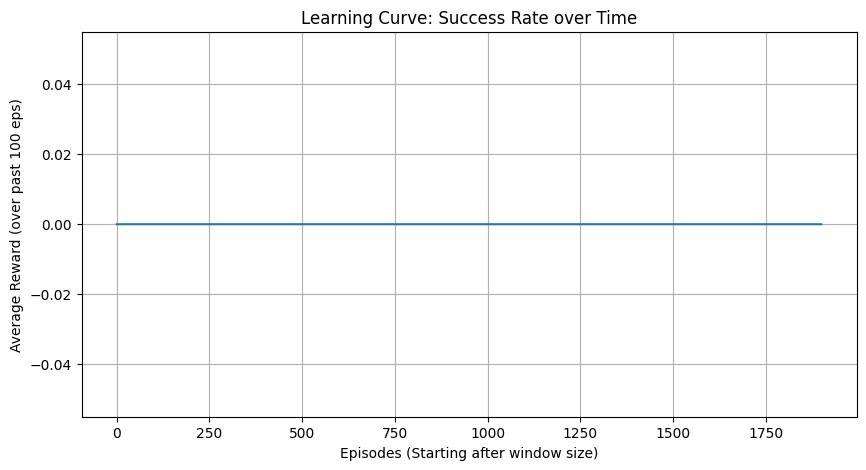

In [8]:
# Calculate moving average to smooth the plot
window_size = 100
moving_avg_rewards = []
for i in range(len(rewards_per_episode) - window_size + 1):
    window = rewards_per_episode[i : i + window_size]
    moving_avg_rewards.append(sum(window) / window_size)

plt.figure(figsize=(10, 5))
plt.plot(moving_avg_rewards)
plt.xlabel('Episodes (Starting after window size)')
plt.ylabel('Average Reward (over past 100 eps)')
plt.title('Learning Curve: Success Rate over Time')
plt.grid(True)
plt.show()

Trained Agent playing (pure exploitation)...


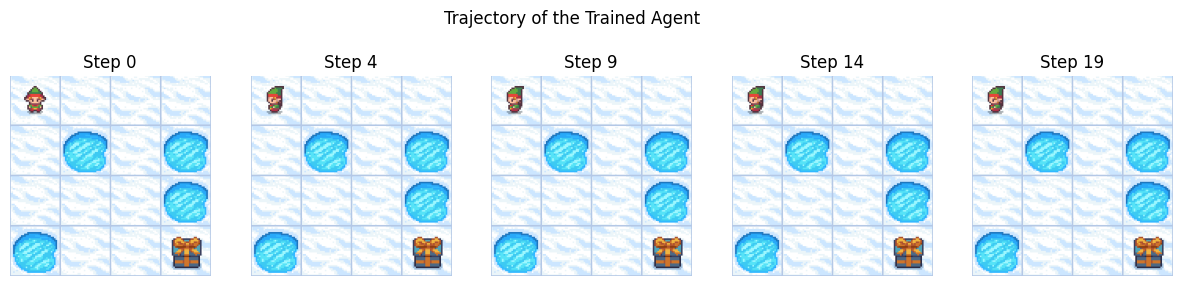

In [9]:
# Setup environment for visualization
env_test = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=False, render_mode="rgb_array")
state, info = env_test.reset(seed=SEED + 100) # Different seed for testing
done = False
frames = [] # To store images of the game

print("Trained Agent playing (pure exploitation)...")

max_test_steps = 20
for step in range(max_test_steps):
    # Render to numpy array for later visualization
    frame = env_test.render()
    frames.append(frame)

    # --- EXPLOITATION ONLY ---
    # Choose the best action based on the trained Q-table
    action = np.argmax(q_table[state, :])

    next_state, reward, terminated, truncated, info = env_test.step(action)
    done = terminated or truncated
    state = next_state

    if done:
        # Capture final frame
        frames.append(env_test.render())
        if reward == 1:
            print("Result: SUCCESS! Reached the goal.")
        else:
            print("Result: FAILED! Fell in a hole.")
        break

env_test.close()

# --- VISUALIZE THE GAME ---
# Display a few key frames from the agent's journey
num_frames_to_show = min(5, len(frames))
fig, axes = plt.subplots(1, num_frames_to_show, figsize=(15, 3))

step_indices = np.linspace(0, len(frames)-1, num_frames_to_show, dtype=int)

for i, ax in enumerate(axes):
    frame_idx = step_indices[i]
    ax.imshow(frames[frame_idx])
    ax.axis('off')
    ax.set_title(f"Step {frame_idx}")

plt.suptitle("Trajectory of the Trained Agent", y=1.05)
plt.show()